In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path += ['../src/']

from model import *

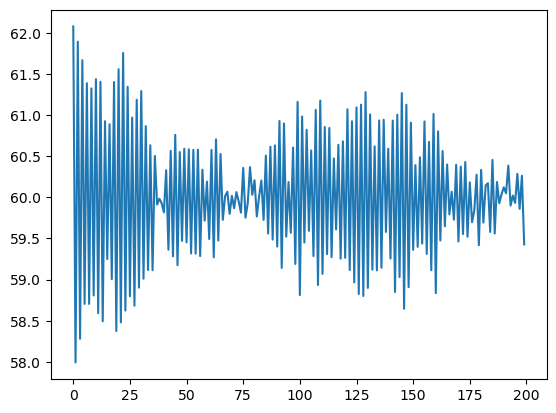

In [2]:
noise_sd = 0.2 #1/4

p_list, pe_list = experiment(treatment="negative",expectations="rule",inputs=[],seed=0,T=200,N=6,noise_sd=noise_sd)
plt.plot(p_list)

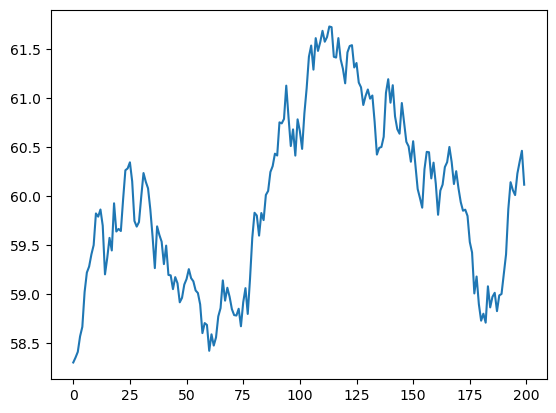

In [4]:
noise_mean = 0
noise_sd = 0.2 #1/4

p_list, pe_list = experiment(treatment="positive",expectations="rule",inputs=[],seed=0,T=200,N=6,noise_sd=noise_sd)
plt.plot(p_list)

In [5]:
file_name="../data/HeemeijeretalJEDC2009-Feedback Experiment - Prices, Predictions.xls"
a=pd.read_excel(file_name)

(0.0, 50.0)

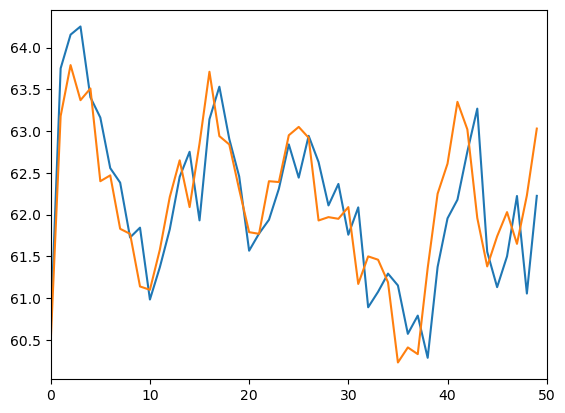

In [7]:
n_experiment = 12
p_exp = a.iloc[4:,7*n_experiment].astype(float).values
pe_exp = a.iloc[4:,np.array(range(1,7))+7*n_experiment].astype(float).values

if n_experiment<6:
    treatment = "negative"
if n_experiment>=6:
    treatment = "positive"
    
noise_sd = 1/4

p_list, pe_list = experiment(treatment=treatment,expectations="experimental",inputs=pe_exp,seed=0,T=50,N=6,noise_sd=noise_sd)
plt.plot(p_list)
plt.plot(p_exp)
#plt.plot(pe_list, color="grey", alpha=0.2)
#plt.ylim(0,100)
plt.xlim(0,50)

In [8]:
p_exp

array([60.48, 63.18, 63.79, 63.37, 63.51, 62.4 , 62.47, 61.83, 61.77,
       61.14, 61.1 , 61.58, 62.21, 62.65, 62.09, 62.85, 63.71, 62.94,
       62.84, 62.3 , 61.79, 61.77, 62.4 , 62.39, 62.95, 63.05, 62.92,
       61.93, 61.97, 61.95, 62.09, 61.17, 61.5 , 61.46, 61.19, 60.23,
       60.41, 60.33, 61.36, 62.25, 62.61, 63.35, 63.02, 61.96, 61.38,
       61.74, 62.03, 61.65, 62.23, 63.03])

In [9]:
pe_list

[array([50.  , 60.25, 55.  , 50.  , 50.  , 96.  ]),
 array([60. , 60.5, 59. , 72. , 65.5, 66. ]),
 array([64.5 , 61.55, 62.  , 64.  , 65.8 , 66.78]),
 array([64.5 , 63.7 , 62.2 , 64.  , 64.  , 64.86]),
 array([63.  , 62.52, 62.5 , 63.5 , 63.1 , 63.89]),
 array([63.5 , 63.45, 63.2 , 63.55, 63.55, 64.21]),
 array([63.  , 62.1 , 62.  , 62.5 , 62.  , 63.01]),
 array([62.5 , 62.2 , 62.5 , 62.5 , 62.55, 63.  ]),
 array([62.  , 62.05, 61.33, 61.9 , 61.6 , 62.16]),
 array([62.8 , 61.6 , 61.58, 61.8 , 61.6 , 61.59]),
 array([61.  , 61.  , 61.08, 61.  , 60.88, 61.01]),
 array([61.2 , 61.  , 61.08, 61.06, 60.99, 61.01]),
 array([61.8 , 61.35, 61.72, 61.5 , 61.95, 61.97]),
 array([62.5 , 62.13, 62.78, 62.5 , 63.  , 62.35]),
 array([62.8 , 62.7 , 62.77, 62.75, 62.75, 62.87]),
 array([62.  , 61.85, 61.95, 62.  , 61.95, 61.89]),
 array([63.  , 62.5 , 62.97, 63.  , 63.  , 62.97]),
 array([63.5 , 63.6 , 63.77, 64.  , 63.95, 63.75]),
 array([63.5 , 62.75, 62.66, 63.  , 62.9 , 63.  ]),
 array([63.  , 62.

In [10]:
mean_earnings_by_exp = []
for n_experiment in range(13):
    p_exp = a.iloc[4:,7*n_experiment].astype(float).values
    pe_exp = a.iloc[4:,np.array(range(1,7))+7*n_experiment].astype(float).values
    mean_earnings_by_exp.append(np.mean(earnings(pe_exp,p_exp[:,np.newaxis]).sum(axis=0)))
print(np.array(mean_earnings_by_exp))
print(np.mean(np.array(mean_earnings_by_exp)))

[22.84148265 21.41268827 20.59422364 22.98371684 22.48374303 21.49130204
 24.24896139 24.48341548 23.99730578 23.83511293 23.83511293 23.26978129
 24.23541276]
23.054789154892724


In [11]:
earnings(pe_exp,p_exp[:,np.newaxis]).sum(axis=0)

array([24.20415816, 24.68758469, 24.3186602 , 23.85641224, 24.23123469,
       24.11442653])

In [12]:
pe_exp[0]

array([50.  , 60.25, 55.  , 50.  , 50.  , 96.  ])

In [14]:
seed = 0
T=50
N=6

np.random.seed(seed)

n_experiment = 12
p_exp = a.iloc[4:,7*n_experiment].astype(float).values
pe_exp = a.iloc[4:,np.array(range(1,7))+7*n_experiment].astype(float).values

if n_experiment<6:
    treatment = "negative"
if n_experiment>=6:
    treatment = "positive"

if treatment == "positive":
    f = f_positive_feedback
if treatment == "negative":
    f = f_negative_feedback

pe = pe_exp[0]
pe_list = [pe]
p_list = []
rewards_list = []
for t in range(1,T+1):
    p = f(pe,noise_mean,noise_sd)
    p_list.append(p)
    rewards_list.append(earnings(pe,p))
    if t<T:
        pe = pe_exp[t]
        pe_list.append(pe)

(0.0, 50.0)

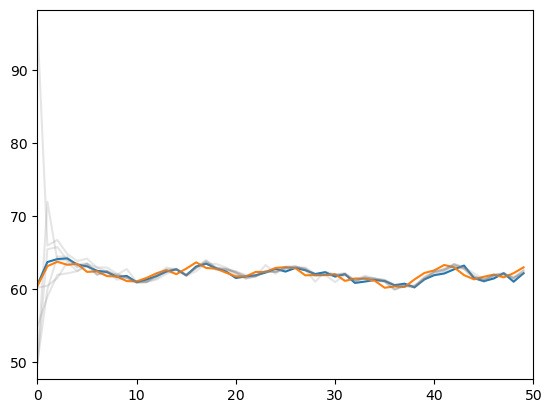

In [15]:
plt.plot(p_list)
plt.plot(p_exp)
plt.plot(pe_list, color="grey", alpha=0.2)
#plt.ylim(0,100)
plt.xlim(0,50)

<Axes: >

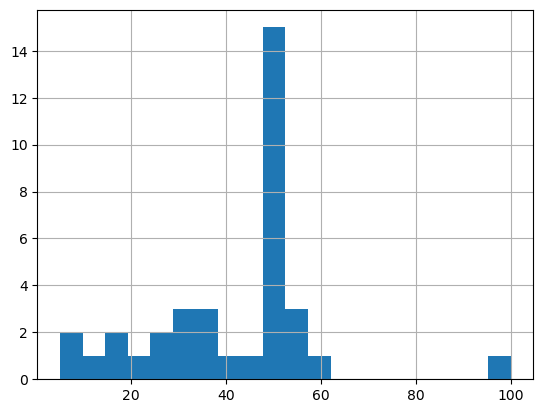

In [16]:
pe_exp_init = []
for n_experiment in range(6):
    pe_exp_init.append(a.iloc[4,np.array(range(1,7))+7*n_experiment].astype(float).values)
    
pd.Series(np.array(pe_exp_init).flatten()).hist(bins=20)

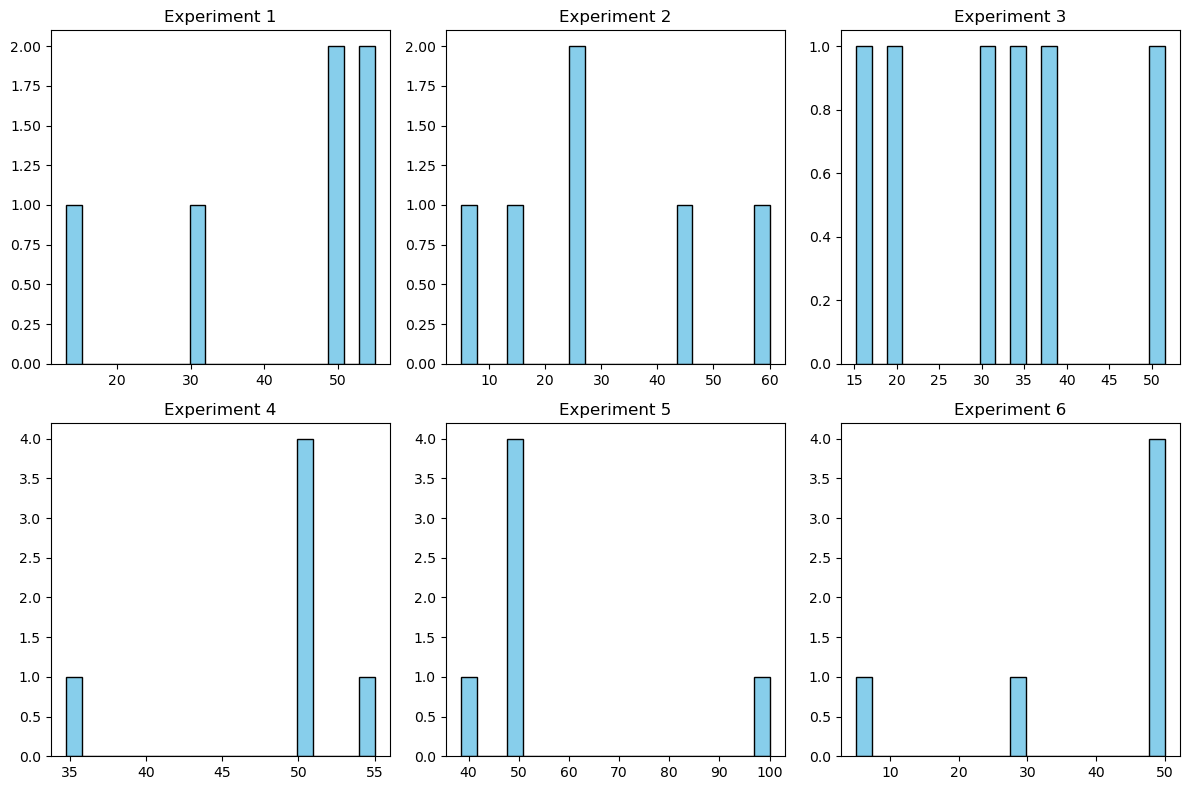

In [17]:
# Create subplots with 2 rows and 3 columns
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))

# Flatten the axes array for easier indexing
axes = axes.flatten()

# List to store the histograms
pe_exp_init_hist = []

# Loop through each experiment
for n_experiment in range(6):
    # Extract data for the current experiment
    data = a.iloc[4, np.array(range(1, 7)) + 7 * n_experiment].astype(float).values
    
    # Create a histogram on the current subplot
    ax = axes[n_experiment]
    ax.hist(data, bins=20, color='skyblue', edgecolor='black')
    ax.set_title(f'Experiment {n_experiment + 1}')
    
    # Store the histogram data for later use (if needed)
    pe_exp_init_hist.append((n_experiment, data))

# Adjust layout for better spacing
plt.tight_layout()

# Show the plots
plt.show()


<Axes: >

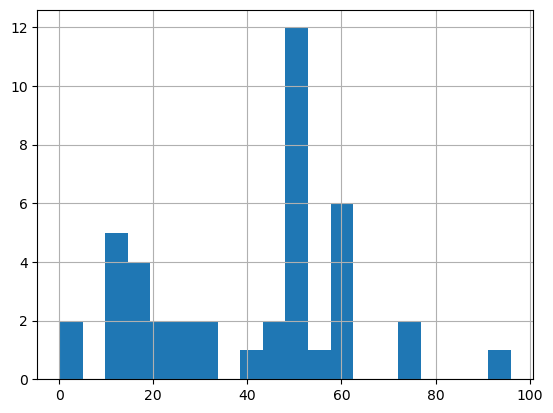

In [18]:
pe_exp_init = []
for n_experiment in range(6,13):
    pe_exp_init.append(a.iloc[4,np.array(range(1,7))+7*n_experiment].astype(float).values)
    
pd.Series(np.array(pe_exp_init).flatten()).hist(bins=20)

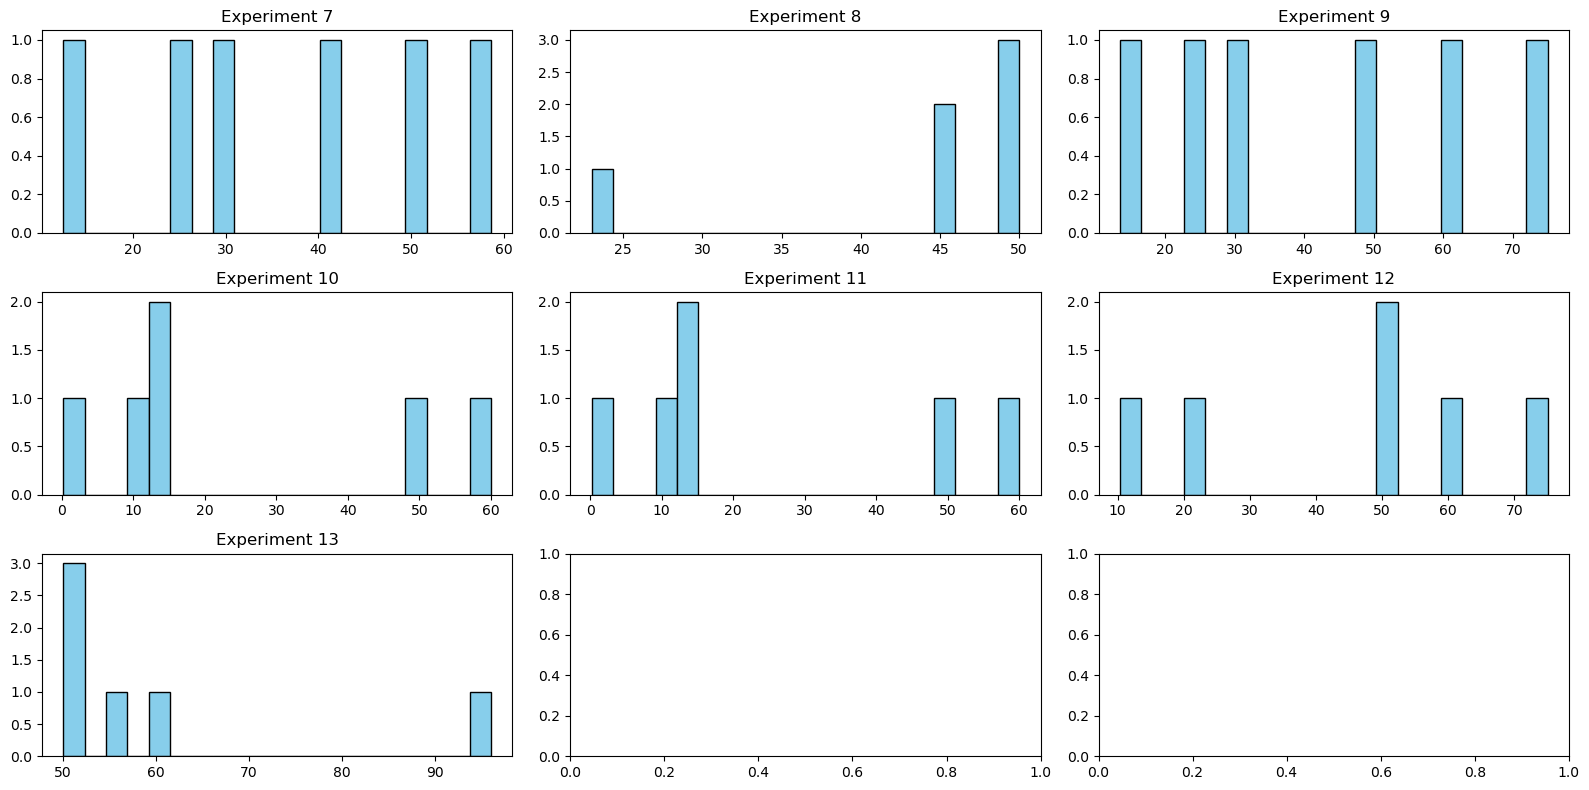

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming 'a' is your DataFrame

# Create subplots with 2 rows and 3 columns
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 8))

# Flatten the axes array for easier indexing
axes = axes.flatten()

# List to store the histograms
pe_exp_init_hist = []

# Loop through each experiment
for n_experiment in range(6,13):
    # Extract data for the current experiment
    data = a.iloc[4, np.array(range(1, 7)) + 7 * n_experiment].astype(float).values
    
    # Create a histogram on the current subplot
    ax = axes[n_experiment-6]
    ax.hist(data, bins=20, color='skyblue', edgecolor='black')
    ax.set_title(f'Experiment {n_experiment + 1}')
    
    # Store the histogram data for later use (if needed)
    pe_exp_init_hist.append((n_experiment, data))

# Adjust layout for better spacing
plt.tight_layout()

# Show the plots
plt.show()
